In [1]:
import glob

images_path = glob.glob("../data/PNG/crop_and_pad/*")

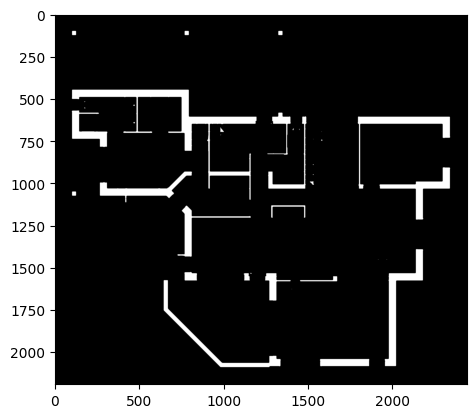

In [2]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(images_path[0], cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(img, cmap="gray")
plt.show()

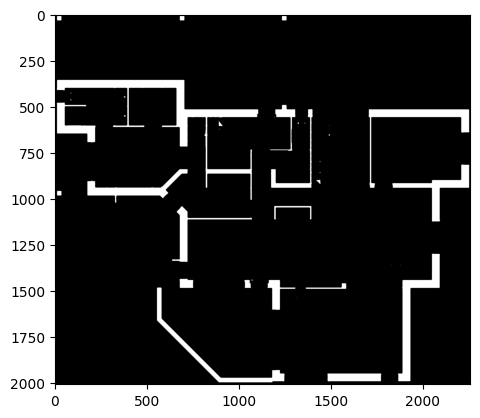

In [3]:
import numpy as np


def crop_to_content(binary, margin=10):
    """Crop binary image to bounding box of white pixels, with inward margin."""
    coords = np.column_stack(np.where(binary > 0))
    if len(coords) == 0:
        return binary
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    h, w = binary.shape
    y_min = max(0, y_min + margin)
    x_min = max(0, x_min + margin)
    y_max = min(h, y_max - margin)
    x_max = min(w, x_max - margin)

    return binary[y_min:y_max, x_min:x_max]


cropped = crop_to_content(binary, margin=-10)

plt.imshow(cropped, cmap="gray")
plt.show()

Kept 20 / 40 components (min_area = 454)


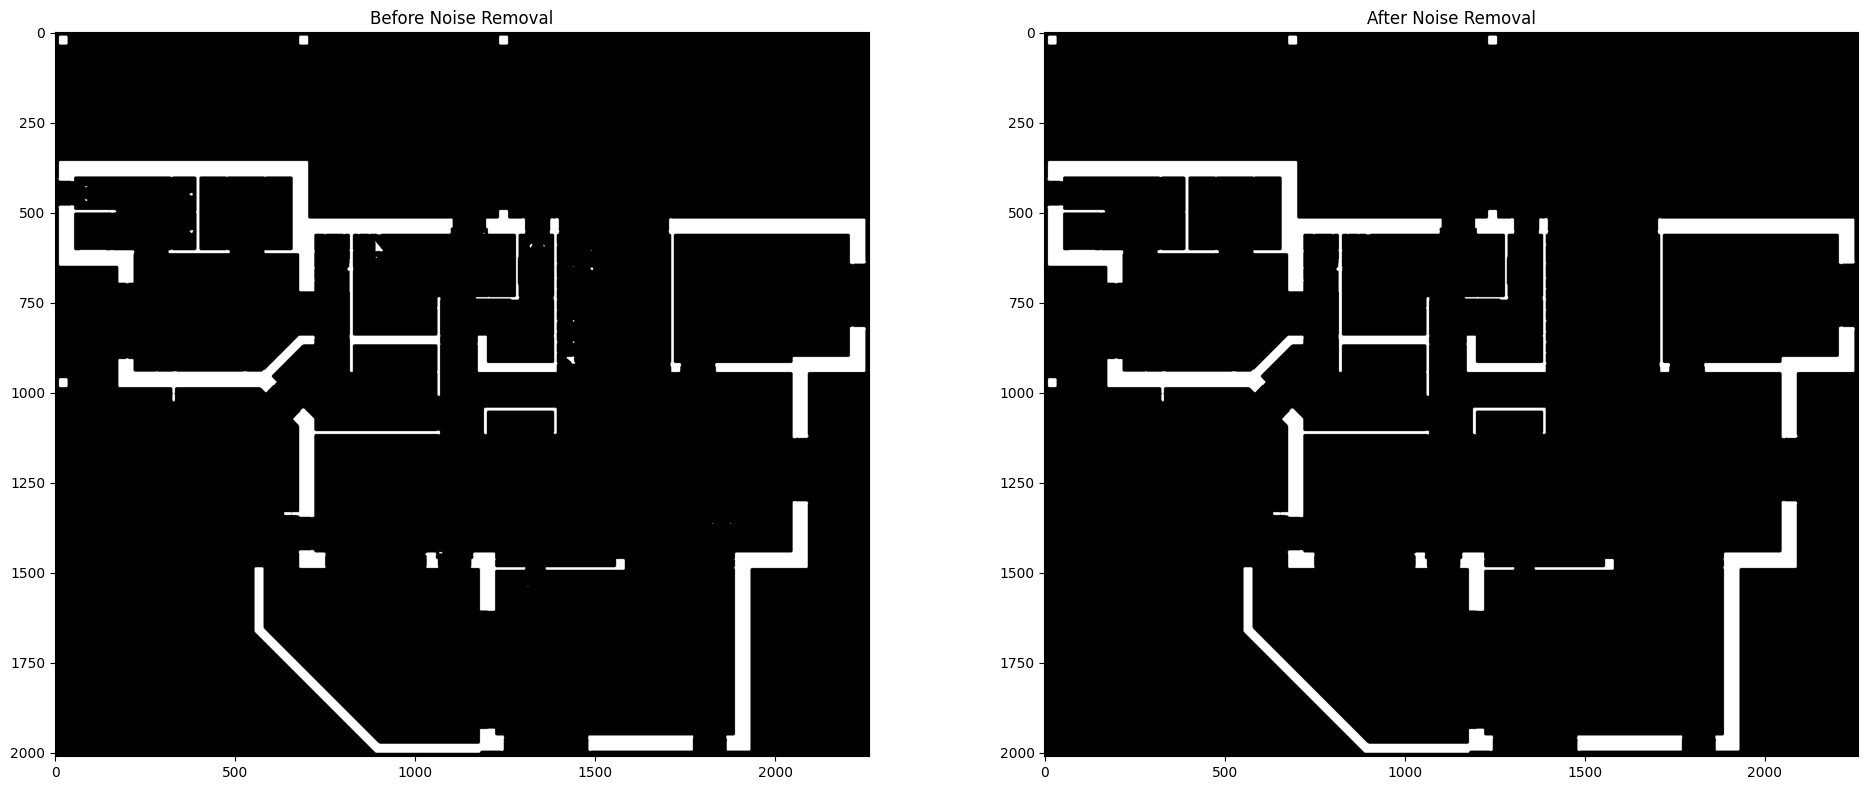

In [4]:
def remove_noise(binary, min_area_ratio=0.0001):
    """
    Remove small connected components.
    min_area_ratio: minimum area as fraction of total image area.
    """
    h, w = binary.shape
    min_area = max(50, int(h * w * min_area_ratio))

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary, connectivity=8
    )

    cleaned = np.zeros_like(binary)
    kept = 0
    for label_id in range(1, num_labels):  # skip background (0)
        if stats[label_id, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == label_id] = 255
            kept += 1

    print(f"Kept {kept} / {num_labels - 1} components (min_area = {min_area})")
    return cleaned


cleaned = remove_noise(cropped, min_area_ratio=0.0001)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(cropped, cmap="gray")
axes[0].set_title("Before Noise Removal")
axes[1].imshow(cleaned, cmap="gray")
axes[1].set_title("After Noise Removal")
plt.tight_layout()
plt.show()

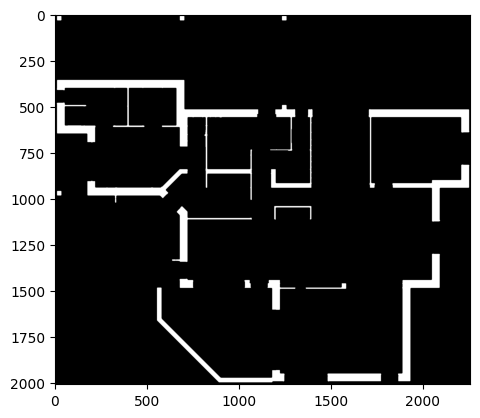

In [5]:
def morphological_cleanup(binary, kernel_size=3):
    """
    Light closing then opening to smooth wall edges.
    Set kernel_size=0 to skip.
    """
    if kernel_size <= 0:
        return binary.copy()

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
    return opened


smoothed = morphological_cleanup(cleaned, kernel_size=3)

plt.imshow(smoothed, cmap="gray")
plt.show()

Polygon corners detected: 228


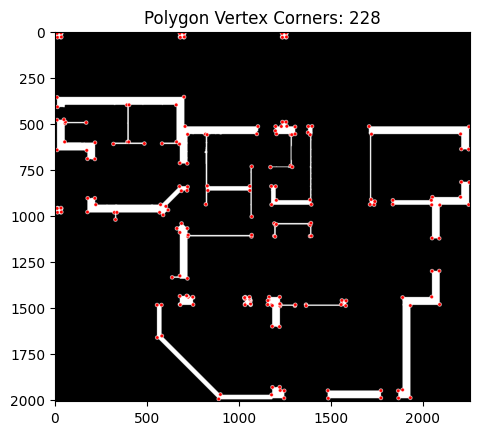

In [6]:
def detect_corners_polygon(binary, min_area=500, epsilon_ratio=0.005):
    """
    Polygon approximation of contours. Vertices = corners.

    epsilon_ratio:
      0.001 -> many vertices (subtle bends)
      0.005 -> moderate (default)
      0.02  -> only sharp corners
    """
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    corners = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue

        epsilon = epsilon_ratio * cv2.arcLength(cnt, closed=True)
        approx = cv2.approxPolyDP(cnt, epsilon, closed=True)

        for pt in approx:
            corners.append(tuple(pt[0]))

    return corners


poly_corners = detect_corners_polygon(smoothed, min_area=500, epsilon_ratio=0.005)
print(f"Polygon corners detected: {len(poly_corners)}")

vis = cv2.cvtColor(smoothed, cv2.COLOR_GRAY2BGR)
for x, y in poly_corners:
    cv2.circle(vis, (int(x), int(y)), 10, (0, 0, 255), -1)
    cv2.circle(vis, (int(x), int(y)), 10, (255, 255, 255), 2)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Polygon Vertex Corners: {len(poly_corners)}")
plt.show()

In [7]:
import os
from pathlib import Path

output_dir = "../data/PNG/corners"
os.makedirs(output_dir, exist_ok=True)
for img_path in images_path:
    fname = os.path.basename(img_path)
    new_path = Path(output_dir, fname)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    cropped = crop_to_content(binary, margin=-10)
    cleaned = remove_noise(cropped, min_area_ratio=0.0001)
    smoothed = morphological_cleanup(cleaned, kernel_size=3)
    poly_corners = detect_corners_polygon(smoothed, min_area=500, epsilon_ratio=0.005)

    vis = cv2.cvtColor(smoothed, cv2.COLOR_GRAY2BGR)
    for x, y in poly_corners:
        cv2.circle(vis, (int(x), int(y)), 10, (0, 0, 255), -1)
        cv2.circle(vis, (int(x), int(y)), 10, (255, 255, 255), 2)

    plt.imsave(new_path, cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))

Kept 20 / 40 components (min_area = 454)
Kept 17 / 61 components (min_area = 432)
Kept 15 / 27 components (min_area = 346)
Kept 15 / 71 components (min_area = 323)
Kept 24 / 97 components (min_area = 281)
Kept 16 / 27 components (min_area = 339)
Kept 20 / 37 components (min_area = 380)
Kept 14 / 58 components (min_area = 342)
Kept 13 / 22 components (min_area = 205)
Kept 15 / 38 components (min_area = 375)
Kept 17 / 33 components (min_area = 201)
Kept 10 / 20 components (min_area = 190)
Kept 18 / 40 components (min_area = 412)
Kept 16 / 34 components (min_area = 534)
Kept 14 / 15 components (min_area = 295)
Kept 16 / 18 components (min_area = 347)
Kept 14 / 33 components (min_area = 327)
Kept 18 / 32 components (min_area = 396)
Kept 12 / 18 components (min_area = 184)
Kept 15 / 73 components (min_area = 321)
Kept 18 / 37 components (min_area = 417)
Kept 16 / 18 components (min_area = 338)
Kept 14 / 25 components (min_area = 354)
Kept 17 / 37 components (min_area = 440)
Kept 11 / 27 com